In [1]:
!pip install kaggle

In [2]:
kaggle = '/content/drive/MyDrive/Praktikum-Tugas_MachineLearning/kaggle.json'

In [3]:
!mkdir -p ~/.kaggle
!cp {kaggle} ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [4]:
!kaggle datasets download -d olafkrastovski/handwritten-digits-0-9

Dataset URL: https://www.kaggle.com/datasets/olafkrastovski/handwritten-digits-0-9
License(s): CC0-1.0
handwritten-digits-0-9.zip: Skipping, found more recently modified local copy (use --force to force download)


In [5]:
from zipfile import ZipFile
import os
file_name = 'handwritten-digits-0-9.zip'

extract_folder = "dataset"
os.makedirs(extract_folder, exist_ok= True)

with ZipFile(file_name, 'r') as zip:
  zip.extractall(extract_folder)
  print ('Done')

Done


In [6]:
data_0 = os.listdir('/content/dataset/0')
data_1 = os.listdir('/content/dataset/1')
data_2 = os.listdir('/content/dataset/2')
data_3 = os.listdir('/content/dataset/3')
data_4 = os.listdir('/content/dataset/4')
data_5 = os.listdir('/content/dataset/5')
data_6 = os.listdir('/content/dataset/6')
data_7 = os.listdir('/content/dataset/7')
data_8 = os.listdir('/content/dataset/8')
data_9 = os.listdir('/content/dataset/9')

In [7]:
len(data_0)

2236

In [9]:
import os
import cv2
import numpy as np

X = []
y = []

dataset_path = '/content/dataset'

for label in range(10):
    folder_path = os.path.join(dataset_path, str(label))
    for img_name in os.listdir(folder_path):
        img_path = os.path.join(folder_path, img_name)

        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        img = cv2.resize(img, (28, 28))

        # 🔧 preprocessing penting
        img = cv2.GaussianBlur(img, (5,5), 0)
        _, img = cv2.threshold(img, 0, 255,
                                cv2.THRESH_BINARY + cv2.THRESH_OTSU)
        img = cv2.bitwise_not(img)  # invert warna

        X.append(img)
        y.append(label)

X = np.array(X, dtype='float32') / 255.0
y = np.array(y)

print(X.shape, y.shape)

(21555, 28, 28) (21555,)


In [10]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [11]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout

mlp_model = Sequential([
    Flatten(input_shape=(28,28)),
    Dense(256, activation='relu'),
    Dropout(0.3),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(10, activation='softmax')
])

mlp_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

mlp_model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 235,146 (918.54 KB)

 Trainable params: 235,146 (918.54 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
history_mlp = mlp_model.fit(
    x_train, y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)


Epoch 1/20
432/432 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.3801 - loss: 1.8042 - val_accuracy: 0.7043 - val_loss: 1.0150
Epoch 2/20
432/432 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.6572 - loss: 1.0572 - val_accuracy: 0.7704 - val_loss: 0.7329
Epoch 3/20
432/432 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.7455 - loss: 0.7724 - val_accuracy: 0.8211 - val_loss: 0.6099
Epoch 4/20
432/432 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8023 - loss: 0.6265 - val_accuracy: 0.8371 - val_loss: 0.5121
Epoch 5/20
432/432 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.8277 - loss: 0.5330 - val_accuracy: 0.8582 - val_loss: 0.4605
Epoch 6/20
432/432 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8425 - loss: 0.4757 - val_accuracy: 0.8655 - val_loss: 0.4269
Epoch 7/20
432/432 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8695 - loss: 0.4039 - val_accuracy: 0.8710 - val_loss: 0.4383
Epoch 8/20
432/432 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.8799 - loss: 0.3626 - val_accuracy: 

In [13]:
test_loss, test_acc = mlp_model.evaluate(x_test, y_test)
print("MLP Test Accuracy:", test_acc)


135/135 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8977 - loss: 0.3552
MLP Test Accuracy: 0.8960797786712646


135/135 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step


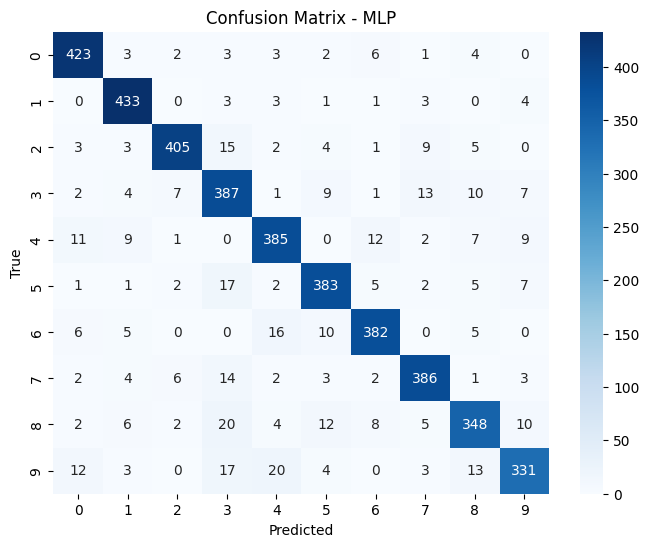

In [14]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

y_pred = mlp_model.predict(x_test)
y_pred_cls = np.argmax(y_pred, axis=1)

cm = confusion_matrix(y_test, y_pred_cls)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix - MLP")
plt.show()


In [15]:
x_train_cnn = x_train.reshape(-1, 28, 28, 1)
x_test_cnn  = x_test.reshape(-1, 28, 28, 1)


In [16]:
from tensorflow.keras.layers import Conv2D, MaxPooling2D

cnn_model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    MaxPooling2D((2,2)),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D((2,2)),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(10, activation='softmax')
])

cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [17]:
history_cnn = cnn_model.fit(
    x_train_cnn, y_train,
    epochs=15,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)


Epoch 1/15
432/432 ━━━━━━━━━━━━━━━━━━━━ 18s 36ms/step - accuracy: 0.4865 - loss: 1.4977 - val_accuracy: 0.8724 - val_loss: 0.4232
Epoch 2/15
432/432 ━━━━━━━━━━━━━━━━━━━━ 20s 35ms/step - accuracy: 0.8305 - loss: 0.5192 - val_accuracy: 0.9162 - val_loss: 0.2720
Epoch 3/15
432/432 ━━━━━━━━━━━━━━━━━━━━ 17s 38ms/step - accuracy: 0.8857 - loss: 0.3541 - val_accuracy: 0.9290 - val_loss: 0.2302
Epoch 4/15
432/432 ━━━━━━━━━━━━━━━━━━━━ 14s 33ms/step - accuracy: 0.9109 - loss: 0.2925 - val_accuracy: 0.9394 - val_loss: 0.1896
Epoch 5/15
432/432 ━━━━━━━━━━━━━━━━━━━━ 14s 33ms/step - accuracy: 0.9235 - loss: 0.2285 - val_accuracy: 0.9475 - val_loss: 0.1748
Epoch 6/15
432/432 ━━━━━━━━━━━━━━━━━━━━ 20s 33ms/step - accuracy: 0.9378 - loss: 0.1913 - val_accuracy: 0.9443 - val_loss: 0.1779
Epoch 7/15
432/432 ━━━━━━━━━━━━━━━━━━━━ 14s 33ms/step - accuracy: 0.9442 - loss: 0.1757 - val_accuracy: 0.9507 - val_loss: 0.1663
Epoch 8/15
432/432 ━━━━━━━━━━━━━━━━━━━━ 21s 35ms/step - accuracy: 0.9506 - loss: 0.1556 - 

In [18]:
cnn_loss, cnn_acc = cnn_model.evaluate(x_test_cnn, y_test)
print("CNN Test Accuracy:", cnn_acc)


135/135 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - accuracy: 0.9651 - loss: 0.1279
CNN Test Accuracy: 0.9626536965370178


135/135 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step


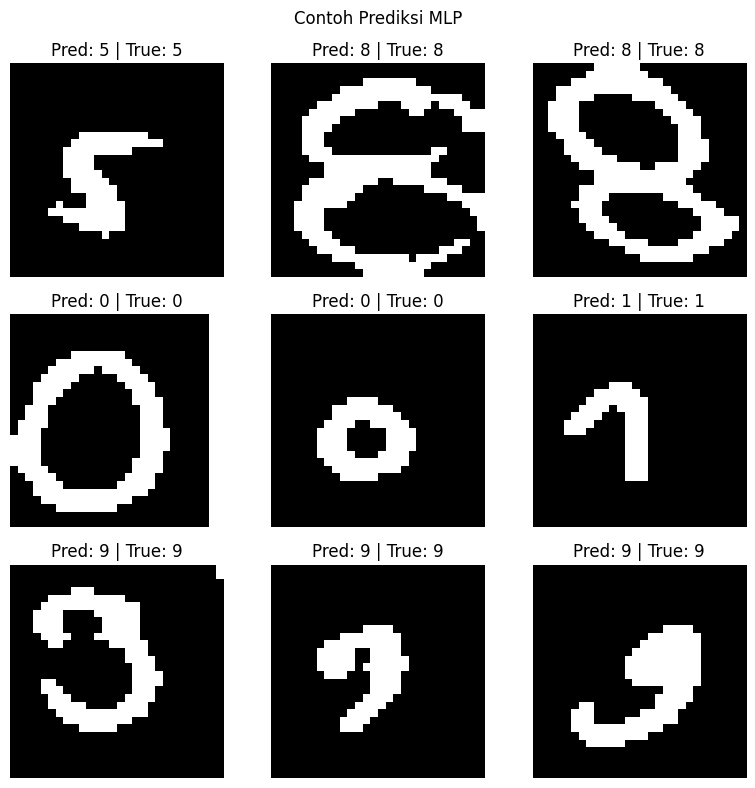

In [19]:
import matplotlib.pyplot as plt
import numpy as np

y_pred = mlp_model.predict(x_test)
y_pred_cls = np.argmax(y_pred, axis=1)

plt.figure(figsize=(8,8))
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(x_test[i], cmap='gray')
    plt.title(f"Pred: {y_pred_cls[i]} | True: {y_test[i]}")
    plt.axis('off')
plt.suptitle("Contoh Prediksi MLP")
plt.tight_layout()
plt.show()
